**IMPORT LIBRARIES**

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

**LOAD and VIEW DATASET**

In [134]:
df=pd.read_csv("/content/sales_dataset_500_rows.csv")
display(df)

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
0,5001,Mouse,Electronics,1,12000.0,15,West,customer1gmail.com
1,5002,Laptop,Electronics,5,1500.0,10,North,customer2@gmail.com
2,5003,Mouse,Electronics,-2,55000.0,0,South,customer3@gmail.com
3,5004,Mouse,Electronics,3,12000.0,0,North,customer4@gmail.com
4,5005,Monitor,Electronics,5,500.0,50,East,customer5gmail.com
...,...,...,...,...,...,...,...,...
495,5496,Laptop,Electronics,3,NaN,15,South,customer496gmail.com
496,5497,Monitor,Electronics,1,1500.0,50,West,customer497gmail.com
497,5498,Tablet,Electronics,-2,12000.0,15,East,customer498gmail.com
498,5499,Monitor,Electronics,5,55000.0,15,North,customer499@gmail.com


**UNDERSTAND THE DATASET**

In [135]:
df.head()

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
0,5001,Mouse,Electronics,1,12000.0,15,West,customer1gmail.com
1,5002,Laptop,Electronics,5,1500.0,10,North,customer2@gmail.com
2,5003,Mouse,Electronics,-2,55000.0,0,South,customer3@gmail.com
3,5004,Mouse,Electronics,3,12000.0,0,North,customer4@gmail.com
4,5005,Monitor,Electronics,5,500.0,50,East,customer5gmail.com


In [136]:
df.tail()

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
495,5496,Laptop,Electronics,3,NaN,15,South,customer496gmail.com
496,5497,Monitor,Electronics,1,1500.0,50,West,customer497gmail.com
497,5498,Tablet,Electronics,-2,12000.0,15,East,customer498gmail.com
498,5499,Monitor,Electronics,5,55000.0,15,North,customer499@gmail.com
499,5500,Monitor,Electronics,1,1500.0,50,East,customer500@gmail.com


In [137]:
df.shape

(500, 8)

In [138]:
df.columns

Index(['Order_ID', 'Product', 'Category', 'Quantity', 'Price', 'Discount',
       'Region', 'Customer_Email'],
      dtype='object')

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    int64  
 1   Product         500 non-null    object 
 2   Category        500 non-null    object 
 3   Quantity        500 non-null    int64  
 4   Price           403 non-null    float64
 5   Discount        500 non-null    int64  
 6   Region          500 non-null    object 
 7   Customer_Email  500 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 31.4+ KB


In [140]:
df.describe()

,Order_ID,Quantity,Price,Discount
count,500.000000,500.000000,403.000000,500.000000
mean,5250.500000,13.924000,16964.019851,14.890000
std,144.481833,31.089151,22322.919991,16.917752
min,5001.000000,-2.000000,500.000000,0.000000
25%,5125.750000,1.000000,500.000000,5.000000
50%,5250.500000,3.000000,1500.000000,10.000000
75%,5375.250000,5.000000,12000.000000,15.000000
max,5500.000000,100.000000,55000.000000,50.000000


**FIND DATATYPES**

In [141]:
df.dtypes

,0
Order_ID,int64
Product,object
Category,object
Quantity,int64
Price,float64
Discount,int64
Region,object
Customer_Email,object


**FIND AND REPLACE MISSING VALUES**

In [142]:
df.isnull()    #returns true/false

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
495,False,False,False,False,True,False,False,False
496,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False


In [143]:
df.isnull().sum()   #returns total count of missing values for each column

,0
Order_ID,0
Product,0
Category,0
Quantity,0
Price,97
Discount,0
Region,0
Customer_Email,0


In [144]:
df['Price'].fillna(df['Price'].median(),inplace=True)   #Replace Price by mode value

/tmp/ipykernel_1082/1040639110.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].median(),inplace=True)   #Replace Price by mode value


In [145]:
df.isnull().sum()

,0
Order_ID,0
Product,0
Category,0
Quantity,0
Price,0
Discount,0
Region,0
Customer_Email,0


**DETECT AND REMOVE DUPLICATES**

In [146]:
df.duplicated().sum()

np.int64(0)

**DATATYPE CONVERSION**

In [147]:
df.dtypes   # all dtypes are correct there is no type conversion

,0
Order_ID,int64
Product,object
Category,object
Quantity,int64
Price,float64
Discount,int64
Region,object
Customer_Email,object


**DATA VALIDATION**

In [148]:
df[df["Price"]<=500]

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
4,5005,Monitor,Electronics,5,500.0,50,East,customer5gmail.com
7,5008,Monitor,Electronics,10,500.0,0,North,customer8@gmail.com
8,5009,Monitor,Electronics,3,500.0,5,North,customer9gmail.com
10,5011,Laptop,Electronics,10,500.0,10,West,customer11gmail.com
24,5025,Monitor,Electronics,100,500.0,15,South,customer25@gmail.com
...,...,...,...,...,...,...,...,...
464,5465,Monitor,Electronics,5,500.0,5,East,customer465gmail.com
471,5472,Mouse,Electronics,5,500.0,0,North,customer472gmail.com
479,5480,Mouse,Electronics,5,500.0,10,West,customer480@gmail.com
485,5486,Monitor,Electronics,3,500.0,10,North,customer486gmail.com


In [149]:
df[df['Quantity']<0]

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
2,5003,Mouse,Electronics,-2,55000.0,0,South,customer3@gmail.com
22,5023,Mouse,Electronics,-2,55000.0,15,East,customer23gmail.com
25,5026,Mouse,Electronics,-2,1500.0,15,South,customer26@gmail.com
26,5027,Monitor,Electronics,-2,12000.0,15,South,customer27gmail.com
33,5034,Monitor,Electronics,-2,500.0,10,South,customer34gmail.com
...,...,...,...,...,...,...,...,...
461,5462,Laptop,Electronics,-2,500.0,5,North,customer462@gmail.com
477,5478,Mouse,Electronics,-2,1500.0,10,West,customer478@gmail.com
480,5481,Keyboard,Electronics,-2,12000.0,10,West,customer481gmail.com
489,5490,Laptop,Electronics,-2,12000.0,5,South,customer490gmail.com


In [150]:
df[~df["Customer_Email"].str.contains("@",na=False)]

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
0,5001,Mouse,Electronics,1,12000.0,15,West,customer1gmail.com
4,5005,Monitor,Electronics,5,500.0,50,East,customer5gmail.com
8,5009,Monitor,Electronics,3,500.0,5,North,customer9gmail.com
10,5011,Laptop,Electronics,10,500.0,10,West,customer11gmail.com
11,5012,Laptop,Electronics,10,55000.0,5,North,customer12gmail.com
...,...,...,...,...,...,...,...,...
493,5494,Keyboard,Electronics,100,1500.0,5,South,customer494gmail.com
494,5495,Mouse,Electronics,5,1500.0,5,East,customer495gmail.com
495,5496,Laptop,Electronics,3,1500.0,15,South,customer496gmail.com
496,5497,Monitor,Electronics,1,1500.0,50,West,customer497gmail.com


In [151]:
df[df["Customer_Email"].str.contains("@",na=False)]

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email
1,5002,Laptop,Electronics,5,1500.0,10,North,customer2@gmail.com
2,5003,Mouse,Electronics,-2,55000.0,0,South,customer3@gmail.com
3,5004,Mouse,Electronics,3,12000.0,0,North,customer4@gmail.com
5,5006,Mouse,Electronics,1,55000.0,5,East,customer6@gmail.com
6,5007,Keyboard,Electronics,10,1500.0,0,West,customer7@gmail.com
...,...,...,...,...,...,...,...,...
487,5488,Monitor,Electronics,3,500.0,15,East,customer488@gmail.com
488,5489,Laptop,Electronics,3,1500.0,10,East,customer489@gmail.com
491,5492,Keyboard,Electronics,2,55000.0,15,West,customer492@gmail.com
498,5499,Monitor,Electronics,5,55000.0,15,North,customer499@gmail.com


In [152]:
df=df[df["Customer_Email"].str.contains("@",na=False)]

In [153]:
df[~df["Customer_Email"].str.contains("@",na=False)]

,Order_ID,Product,Category,Quantity,Price,Discount,Region,Customer_Email


In [154]:
df['Customer_Email'].is_unique

True

**SKEWNESS AND KURTOSIS**

In [155]:
df['Price'].skew()

np.float64(1.2176424179003602)

In [156]:
df['Price'].kurt()

np.float64(-0.41302106816113016)

**OUTLIER DETECTION AND HANDLING**

**FIND OUTLIERS USING IQR METHOD**

In [157]:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df['Price']<lower)|(df['Price']>upper)]
print(outliers)

     Order_ID   Product     Category  Quantity    Price  Discount Region  \
2        5003     Mouse  Electronics        -2  55000.0         0  South   
5        5006     Mouse  Electronics         1  55000.0         5   East   
23       5024    Tablet  Electronics         3  55000.0        10  South   
71       5072  Keyboard  Electronics       100  55000.0        15  South   
87       5088     Mouse  Electronics         3  55000.0        15   West   
103      5104    Laptop  Electronics         2  55000.0        10   West   
105      5106    Tablet  Electronics         3  55000.0         5   East   
106      5107  Keyboard  Electronics       100  55000.0         0   East   
107      5108    Tablet  Electronics        10  55000.0        15  South   
110      5111     Mouse  Electronics         3  55000.0        10  South   
118      5119   Monitor  Electronics        -2  55000.0        10  South   
126      5127    Tablet  Electronics        10  55000.0         0   East   
140      514

REMOVE OUTLIERS

In [158]:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df_cleaned_outliers=df[(df['Price']>=lower)&(df['Price']<=upper)]
print(df_cleaned_outliers)

     Order_ID   Product     Category  Quantity    Price  Discount Region  \
1        5002    Laptop  Electronics         5   1500.0        10  North   
3        5004     Mouse  Electronics         3  12000.0         0  North   
6        5007  Keyboard  Electronics        10   1500.0         0   West   
7        5008   Monitor  Electronics        10    500.0         0  North   
9        5010    Laptop  Electronics         3   1500.0        15  North   
..        ...       ...          ...       ...      ...       ...    ...   
481      5482  Keyboard  Electronics         3   1500.0         0   East   
486      5487    Laptop  Electronics         2  12000.0        50  North   
487      5488   Monitor  Electronics         3    500.0        15   East   
488      5489    Laptop  Electronics         3   1500.0        10   East   
499      5500   Monitor  Electronics         1   1500.0        50   East   

            Customer_Email  
1      customer2@gmail.com  
3      customer4@gmail.com  


**BOX PLOT FOR DETECTING OUTLIERS**

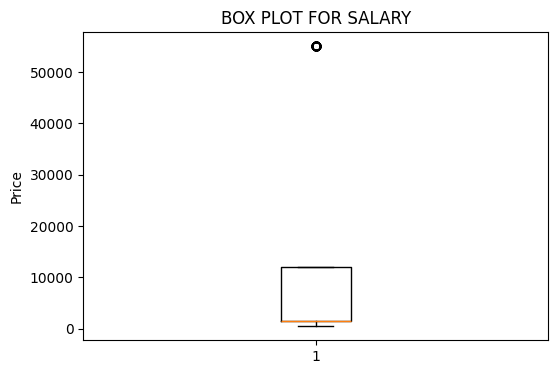

In [159]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Price"])
plt.title("BOX PLOT FOR SALARY")
plt.ylabel("Price")
plt.show()

**SELECT NUMERIC** **COLUMNS**

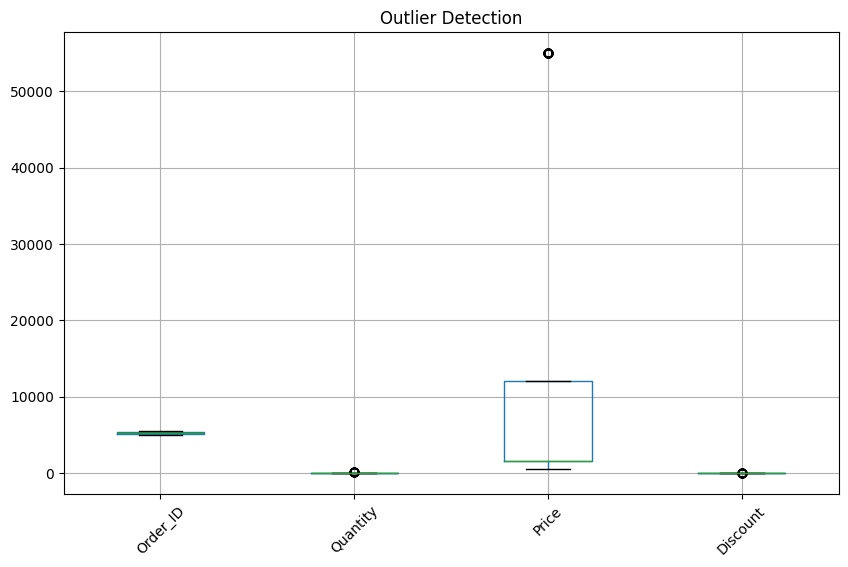

In [160]:
numeric_cols=df.select_dtypes(include="number")
#plot
numeric_cols.boxplot(figsize=(10,6))
plt.title("Outlier Detection")
plt.xticks(rotation=45)
plt.show()